# F_S3.3 — Branch Detector Test (F23/F24 + other families)

Branch-only evaluation. The notebook stops after MIC gating and branch detection.
Each of the five KDE bandwidths independently completes local-mode detection and
cross-window tracking. Branch requires at least 3/5 explicit Branch votes.
Candidate requires at least 2/5 Branch-or-Candidate support votes, including at
least one explicit Branch vote, with median relative mode separation ≥ 0.90. It
does not run dCor, Pearson routing,
power-law fitting, or SiZer.

**Candidate branch** is a detector output, never a ground-truth label.

Two diagnostic tables:

1. **F23/F24 (visible forks)** — expected labels are Branch / Uncertain /
   No Global Relationship, assigned from nominal SNR. Uncertain rows are shown
   but not scored.
2. **Other families (not forks)** — F25/F26 included as negatives, not as Branch.
   Expected is No branch when MIC ≥ 0.20, otherwise No Global Relationship.

Counts are shown with row percentages. A short TPR / FPR summary follows table 2.

The expensive local multi-bandwidth KDE peak/valley summaries are cached in a
separate Parquet file. Changing downstream gates, fork metrics, or voting rules
therefore only reruns classification; set `REFIT_KDE=True` only after changing
the KDE bandwidths, window construction, or peak/valley extraction itself.


In [11]:
%matplotlib inline
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output, display
from tqdm.auto import tqdm


def locate_repo_root() -> Path:
    for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError('Could not locate the synthetic repository root.')


REPO_ROOT = locate_repo_root()
CASE_A_DIR = REPO_ROOT / 'case' / 'caseA'
if str(CASE_A_DIR) not in sys.path:
    sys.path.insert(0, str(CASE_A_DIR))

import importlib
import multiband_kde_branch_classifier as branch_classifier
importlib.reload(branch_classifier)
from multiband_kde_branch_classifier import (
    BANDWIDTH_FACTORS, CLASSIFIER_VERSION, classifier_signature,
    fit_kde, classify_from_fitted, prepare_panel_xy,
)
print('Branch classifier:', classifier_signature())

SPREAD_PATTERN = 'constant'
X_DISTRIBUTION = 'even'
FORK_FAMILIES = ['F23', 'F24']
OTHER_FAMILIES = [
    'F01', 'F03', 'F05', 'F07', 'F13', 'F15',
    'F18', 'F19', 'F21', 'F22', 'F25', 'F26',
]
FAMILY_FILTER = FORK_FAMILIES + OTHER_FAMILIES
VARIANT_FILTER = ['mild', 'standard', 'strong']
REPEAT_FILTER = [1]
MIC_MIN = 0.0
REFIT_KDE = False       # False: 读取已保存的局部 KDE；True: 强制重新拟合
KDE_MIN_WINDOW = 40
KDE_CACHE_VERSION = CLASSIFIER_VERSION  # 自动校验拟合配置

INPUT_DIR = (
    REPO_ROOT / 'F' / 'output' / 'E' / 'E_S1'
    / SPREAD_PATTERN / 'selected' / X_DISTRIBUTION
)
METRICS_DIR = (
    REPO_ROOT / 'F' / 'output' / 'E' / 'E_S2'
    / SPREAD_PATTERN / 'selected' / X_DISTRIBUTION
)
OUTPUT_DIR = (
    REPO_ROOT / 'F' / 'output' / 'F_S3.3_caseA_classifier_test'
    / SPREAD_PATTERN / X_DISTRIBUTION
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
KDE_CACHE_PATH = OUTPUT_DIR / 'local_multimodal_kde_5bw.parquet'
PREDICTIONS_PATH = OUTPUT_DIR / 'branch_predictions_5bw.csv'

FAMILY_NAMES = {
    'F01': 'Linear positive',
    'F03': 'Power convex positive',
    'F05': 'Power concave positive',
    'F07': 'Saturation positive',
    'F13': 'S-curve positive',
    'F15': 'Threshold positive',
    'F18': 'Quadratic valley (U)',
    'F19': 'Spike',
    'F21': 'Cubic',
    'F22': 'Oscillation',
    'F23': 'Two Lines',
    'F24': 'Line and Parabola',
    'F25': 'Multi-regime threshold',
    'F26': 'Windowed threshold',
}

# Human-visible expected labels for fork families only.
# Candidate branch is reserved exclusively for classifier predictions.
VISIBLE_EXPECTED_RULES = {
    'F23': [
        (5.0, 'Branch'),
        (2.0, 'Branch'),
        (1.2, 'Uncertain'),
        (0.0, 'No Global Relationship'),
    ],
    'F24': [
        (2.0, 'Branch'),
        (1.5, 'Branch'),
        (1.2, 'Uncertain'),
        (0.0, 'No Global Relationship'),
    ],
}

PREDICTED_ORDER = [
    'Branch', 'Candidate branch', 'No branch', 'No Global Relationship',
]


def visible_expected(family_id: str, nominal_snr: float) -> str:
    snr = float(nominal_snr)
    for threshold, label in VISIBLE_EXPECTED_RULES[family_id]:
        if snr >= threshold:
            return label
    return 'No Global Relationship'


def assign_expected(family_id: str, nominal_snr: float, mic: float) -> str:
    if family_id in FORK_FAMILIES:
        return visible_expected(family_id, nominal_snr)
    if np.isfinite(mic) and mic >= MIC_MIN:
        return 'No branch'
    return 'No Global Relationship'


def diagnostic_with_rates(df: pd.DataFrame, expected_cats: list[str]) -> pd.DataFrame:
    """One row per family_id × observed expected label. Name is 1:1 with family."""
    work = df.copy()
    counts = (
        work.groupby(['family_id', 'expected'], sort=False)['predicted_group']
        .value_counts()
        .unstack(fill_value=0)
    )
    for col in PREDICTED_ORDER:
        if col not in counts.columns:
            counts[col] = 0
    counts = counts.reindex(columns=PREDICTED_ORDER, fill_value=0)
    n = counts.sum(axis=1).astype(int)
    counts = counts.loc[n > 0].copy()
    n = n.loc[counts.index]
    out = pd.DataFrame({'Expected N': n}, index=counts.index)
    for col in PREDICTED_ORDER:
        pct = counts[col].to_numpy() / n.to_numpy()
        out[col] = [f'{int(c)} ({p:.1%})' for c, p in zip(counts[col], pct)]
    out = out.reset_index()
    out.insert(1, 'name', out['family_id'].map(FAMILY_NAMES))
    fam_order = [fid for fid in FAMILY_FILTER if fid in set(out['family_id'])]
    out['family_id'] = pd.Categorical(out['family_id'], categories=fam_order, ordered=True)
    out['expected'] = pd.Categorical(out['expected'], categories=expected_cats, ordered=True)
    out = out.sort_values(['family_id', 'expected']).reset_index(drop=True)
    out['family_id'] = out['family_id'].astype(str)
    out['expected'] = out['expected'].astype(str)
    total = counts.sum(axis=0)
    total_n = int(total.sum())
    total_row = {
        'family_id': 'All',
        'name': '',
        'expected': '',
        'Expected N': total_n,
    }
    for col in PREDICTED_ORDER:
        p = (int(total[col]) / total_n) if total_n else 0.0
        total_row[col] = f'{int(total[col])} ({p:.1%})'
    out = pd.concat([out, pd.DataFrame([total_row])], ignore_index=True)
    return out.rename(columns={
        'family_id': 'Family',
        'name': 'Name',
        'expected': 'Expected label',
    })


def show_full(df: pd.DataFrame) -> None:
    with pd.option_context(
        'display.max_rows', None,
        'display.max_columns', None,
        'display.width', None,
        'display.max_colwidth', None,
        'display.expand_frame_repr', False,
    ):
        display(df)


cases = pd.read_csv(INPUT_DIR / 'cases.csv', low_memory=False)
cases = cases[
    cases['family_id'].isin(FAMILY_FILTER)
    & cases['variant_level'].isin(VARIANT_FILTER)
    & cases['repeat'].isin(REPEAT_FILTER)
].copy()
cases['point_index'] = pd.to_numeric(cases['candidate_index'], errors='raise').astype(np.int64)

metrics = pd.read_parquet(
    METRICS_DIR / 'metrics_full.parquet',
    columns=['case_id', 'MIC'],
)
data = cases.merge(metrics, on='case_id', how='inner', validate='one_to_one')
data['name'] = data['family_id'].map(FAMILY_NAMES)
data['expected'] = [
    assign_expected(fid, snr, mic)
    for fid, snr, mic in zip(data['family_id'], data['nominal_snr'], data['MIC'])
]

points = np.load(INPUT_DIR / 'scatter_points.npz')
x_all, y_all = points['x'], points['y']
del points

print(f'Loaded {len(data):,} cases')
print('Fork families :', FORK_FAMILIES)
print('Other families:', OTHER_FAMILIES)

Branch classifier: {'classifier_version': '5bw-consensus-v1', 'bandwidth_factors': (0.65, 0.8, 1.0, 1.25, 1.5), 'min_valley_depth': 0.3, 'min_branch_mass': 0.1, 'min_two_window_fork_score': 0.15, 'min_three_window_fork_score': 0.2, 'min_branch_votes': 3, 'min_candidate_support_votes': 2, 'min_candidate_branch_votes': 1, 'min_candidate_relative_mode_separation': 0.9, 'triplet_jump_filter': False}
Loaded 9,534 cases
Fork families : ['F23', 'F24']
Other families: ['F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18', 'F19', 'F21', 'F22', 'F25', 'F26']


In [12]:
KDE_CACHE_COLUMNS = [
    'case_id', 'cache_version', 'min_window', 'bandwidth_factor',
    'window_index', 'x_min', 'x_mid', 'x_max', 'y_median',
    'mode_low', 'mode_high', 'valley', 'median_valley_depth',
    'median_peak_valley_score', 'median_branch_mass',
    'median_mode_separation', 'median_peak_height_ratio',
    'n_bandwidth_pairs',
]


def _fit_to_cache_rows(case_id, fitted):
    rows = []
    for factor, window_points in fitted['bandwidth_points'].items():
        for window_index, point in enumerate(window_points):
            mode_low, mode_high = point['modes']
            rows.append({
                'case_id': str(case_id),
                'cache_version': KDE_CACHE_VERSION,
                'min_window': KDE_MIN_WINDOW,
                'bandwidth_factor': float(factor),
                'window_index': int(window_index),
                'x_min': point['x_min'],
                'x_mid': point['x_mid'],
                'x_max': point['x_max'],
                'y_median': point['y_median'],
                'mode_low': mode_low,
                'mode_high': mode_high,
                'valley': point['valley'],
                'median_valley_depth': point['median_valley_depth'],
                'median_peak_valley_score': point['median_peak_valley_score'],
                'median_branch_mass': point['median_branch_mass'],
                'median_mode_separation': point['median_mode_separation'],
                'median_peak_height_ratio': point['median_peak_height_ratio'],
                'n_bandwidth_pairs': point['n_bandwidth_pairs'],
            })
    return rows


def _restore_fitted_panel(case_rows, x, y):
    x_prepared, y_prepared = prepare_panel_xy(x, y)
    bandwidth_points = {float(f): [] for f in BANDWIDTH_FACTORS}
    ordered = case_rows.sort_values(['bandwidth_factor', 'window_index'])
    for row in ordered.itertuples(index=False):
        factor = float(row.bandwidth_factor)
        bandwidth_points[factor].append({
            'x_min': float(row.x_min),
            'x_mid': float(row.x_mid),
            'x_max': float(row.x_max),
            'y_median': float(row.y_median),
            'modes': (float(row.mode_low), float(row.mode_high)),
            'valley': float(row.valley),
            'median_valley_depth': float(row.median_valley_depth),
            'median_peak_valley_score': float(row.median_peak_valley_score),
            'median_branch_mass': float(row.median_branch_mass),
            'median_mode_separation': float(row.median_mode_separation),
            'median_peak_height_ratio': float(row.median_peak_height_ratio),
            'n_bandwidth_pairs': int(row.n_bandwidth_pairs),
            'bandwidth_factor': factor,
        })
    return {
        'x': x_prepared,
        'y': y_prepared,
        'bandwidth_points': bandwidth_points,
        'min_window': KDE_MIN_WINDOW,
    }


# ------------------------------------------------------------------
# Stage A: expensive local KDE fitting.  Reuse this Parquet cache.
# ------------------------------------------------------------------
if KDE_CACHE_PATH.exists() and not REFIT_KDE:
    kde_cache = pd.read_parquet(KDE_CACHE_PATH)
    kde_cache['case_id'] = kde_cache['case_id'].astype(str)
    versions = set(kde_cache['cache_version'].dropna().astype(str))
    min_windows = set(kde_cache['min_window'].dropna().astype(int))
    cached_factors = set(kde_cache['bandwidth_factor'].dropna().astype(float))
    expected_factors = set(map(float, BANDWIDTH_FACTORS))
    if (versions != {KDE_CACHE_VERSION}
            or min_windows != {KDE_MIN_WINDOW}
            or cached_factors != expected_factors):
        raise RuntimeError(
            'KDE cache configuration differs from the current detector. '
            'Set REFIT_KDE=True once to rebuild it.'
        )
    print(f'Loaded KDE cache: {KDE_CACHE_PATH} ({len(kde_cache):,} window-bandwidth rows)')
else:
    kde_cache = pd.DataFrame(columns=KDE_CACHE_COLUMNS)

eligible = data[pd.to_numeric(data['MIC'], errors='coerce').ge(MIC_MIN)].copy()
cached_ids = set(kde_cache['case_id'].astype(str)) if len(kde_cache) else set()
missing = eligible[~eligible['case_id'].astype(str).isin(cached_ids)]

if len(missing):
    print(f'Fitting local KDE for {len(missing):,} uncached cases ...')
    new_frames = []
    batch_rows = []
    for fit_i, row in enumerate(tqdm(
        missing.itertuples(index=False), total=len(missing),
        desc='Local multi-bandwidth KDE', leave=False,
    ), start=1):
        fitted = fit_kde(
            x_all[int(row.point_index)],
            y_all[int(row.point_index)],
            min_window=KDE_MIN_WINDOW,
        )
        batch_rows.extend(_fit_to_cache_rows(row.case_id, fitted))
        if fit_i % 100 == 0:
            new_frames.append(pd.DataFrame(batch_rows, columns=KDE_CACHE_COLUMNS))
            batch_rows = []
    if batch_rows:
        new_frames.append(pd.DataFrame(batch_rows, columns=KDE_CACHE_COLUMNS))
    kde_cache = pd.concat([kde_cache, *new_frames], ignore_index=True)
    kde_cache = kde_cache.drop_duplicates(
        ['case_id', 'bandwidth_factor', 'window_index'], keep='last',
    ).sort_values(['case_id', 'bandwidth_factor', 'window_index'])
    kde_cache.to_parquet(KDE_CACHE_PATH, index=False, compression='zstd')
    print(f'Saved KDE cache: {KDE_CACHE_PATH} ({len(kde_cache):,} rows)')
elif not KDE_CACHE_PATH.exists():
    kde_cache.to_parquet(KDE_CACHE_PATH, index=False, compression='zstd')

kde_cache_indexed = kde_cache.set_index('case_id', drop=False).sort_index()


# ------------------------------------------------------------------
# Stage B: cheap downstream classification from the saved KDE layer.
# ------------------------------------------------------------------
prediction_rows = []
for row in tqdm(
    data.itertuples(index=False),
    total=len(data),
    desc='Branch classification from KDE cache',
    leave=False,
):
    mic = float(row.MIC) if pd.notna(row.MIC) else np.nan
    if not np.isfinite(mic) or mic < MIC_MIN:
        predicted = 'No Global Relationship'
        branch_votes = np.nan
        support_votes = np.nan
        vote_pattern = None
        high_confidence = False
        support_median_separation = np.nan
    else:
        case_id = str(row.case_id)
        if case_id not in kde_cache_indexed.index:
            raise KeyError(f'Missing KDE cache rows for {case_id}')
        case_rows = kde_cache_indexed.loc[[case_id]].reset_index(drop=True)
        fitted = _restore_fitted_panel(
            case_rows,
            x_all[int(row.point_index)],
            y_all[int(row.point_index)],
        )
        result = classify_from_fitted(fitted, coverage_mode='x_range')
        predicted = result['group']
        branch_votes = result.get('bandwidth_branch_votes', np.nan)
        support_votes = result.get('bandwidth_support_votes', np.nan)
        vote_pattern = result.get('bandwidth_vote_pattern')
        high_confidence = bool(result.get('high_confidence_branch', False))
        support_median_separation = result.get(
            'bandwidth_support_median_relative_mode_separation', np.nan,
        )
    prediction_rows.append({
        'case_id': row.case_id,
        'predicted_group': predicted,
        'branch_votes': branch_votes,
        'support_votes': support_votes,
        'vote_pattern': vote_pattern,
        'high_confidence_branch': high_confidence,
        'support_median_relative_mode_separation': support_median_separation,
    })

predictions = pd.DataFrame(prediction_rows)
predictions.to_csv(PREDICTIONS_PATH, index=False)
prediction_columns = [col for col in predictions.columns if col != 'case_id']
data = data.drop(columns=prediction_columns, errors='ignore')
data = data.merge(predictions, on='case_id', how='left', validate='one_to_one')

# ------------------------------------------------------------------
# Table 1a — standard + strong
# ------------------------------------------------------------------
fork_data = data[data['family_id'].isin(FORK_FAMILIES)].copy()

fork_ss = fork_data[fork_data['variant_level'].isin(['standard', 'strong'])].copy()
fork_table_ss = diagnostic_with_rates(
    fork_ss,
    ['Branch', 'Uncertain', 'No Global Relationship'],
)

clear_output(wait=True)
print(f'KDE cache: {KDE_CACHE_PATH}')
print(f'Predictions: {PREDICTIONS_PATH}')
print()
print('=' * 70)
print('Table 1a — F23/F24 standard + strong (row % of Expected N)')
print('=' * 70)
show_full(fork_table_ss)

# ------------------------------------------------------------------
# Table 1b — mild
# ------------------------------------------------------------------
fork_mild = fork_data[fork_data['variant_level'] == 'mild'].copy()
fork_table_mild = diagnostic_with_rates(
    fork_mild,
    ['Branch', 'Uncertain', 'No Global Relationship'],
)
print()
print('=' * 70)
print('Table 1b — F23/F24 mild (row % of Expected N)')
print('=' * 70)
show_full(fork_table_mild)

# ------------------------------------------------------------------
# Table 1c — all variant levels
# ------------------------------------------------------------------
fork_table_all = diagnostic_with_rates(
    fork_data,
    ['Branch', 'Uncertain', 'No Global Relationship'],
)
print()
print('=' * 70)
print('Table 1c — F23/F24 all variants (row % of Expected N)')
print('=' * 70)
show_full(fork_table_all)

KDE cache: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S3.3_caseA_classifier_test/constant/even/local_multimodal_kde_5bw.parquet
Predictions: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/F_S3.3_caseA_classifier_test/constant/even/branch_predictions_5bw.csv

Table 1a — F23/F24 standard + strong (row % of Expected N)


,Family,Name,Expected label,Expected N,Branch,Candidate branch,No branch,No Global Relationship
0,F23,Two Lines,Branch,222,196 (88.3%),0 (0.0%),26 (11.7%),0 (0.0%)
1,F23,Two Lines,Uncertain,16,0 (0.0%),0 (0.0%),16 (100.0%),0 (0.0%)
2,F23,Two Lines,No Global Relationship,216,0 (0.0%),0 (0.0%),216 (100.0%),0 (0.0%)
3,F24,Line and Parabola,Branch,232,200 (86.2%),0 (0.0%),32 (13.8%),0 (0.0%)
4,F24,Line and Parabola,Uncertain,6,0 (0.0%),0 (0.0%),6 (100.0%),0 (0.0%)
5,F24,Line and Parabola,No Global Relationship,216,0 (0.0%),0 (0.0%),216 (100.0%),0 (0.0%)
6,All,,,908,396 (43.6%),0 (0.0%),512 (56.4%),0 (0.0%)



Table 1b — F23/F24 mild (row % of Expected N)


,Family,Name,Expected label,Expected N,Branch,Candidate branch,No branch,No Global Relationship
0,F23,Two Lines,Branch,111,67 (60.4%),0 (0.0%),44 (39.6%),0 (0.0%)
1,F23,Two Lines,Uncertain,8,0 (0.0%),0 (0.0%),8 (100.0%),0 (0.0%)
2,F23,Two Lines,No Global Relationship,108,0 (0.0%),0 (0.0%),108 (100.0%),0 (0.0%)
3,F24,Line and Parabola,Branch,116,106 (91.4%),0 (0.0%),10 (8.6%),0 (0.0%)
4,F24,Line and Parabola,Uncertain,3,0 (0.0%),0 (0.0%),3 (100.0%),0 (0.0%)
5,F24,Line and Parabola,No Global Relationship,108,0 (0.0%),0 (0.0%),108 (100.0%),0 (0.0%)
6,All,,,454,173 (38.1%),0 (0.0%),281 (61.9%),0 (0.0%)



Table 1c — F23/F24 all variants (row % of Expected N)


,Family,Name,Expected label,Expected N,Branch,Candidate branch,No branch,No Global Relationship
0,F23,Two Lines,Branch,333,263 (79.0%),0 (0.0%),70 (21.0%),0 (0.0%)
1,F23,Two Lines,Uncertain,24,0 (0.0%),0 (0.0%),24 (100.0%),0 (0.0%)
2,F23,Two Lines,No Global Relationship,324,0 (0.0%),0 (0.0%),324 (100.0%),0 (0.0%)
3,F24,Line and Parabola,Branch,348,306 (87.9%),0 (0.0%),42 (12.1%),0 (0.0%)
4,F24,Line and Parabola,Uncertain,9,0 (0.0%),0 (0.0%),9 (100.0%),0 (0.0%)
5,F24,Line and Parabola,No Global Relationship,324,0 (0.0%),0 (0.0%),324 (100.0%),0 (0.0%)
6,All,,,1362,569 (41.8%),0 (0.0%),793 (58.2%),0 (0.0%)


Missed branch cases: 112
family_id  variant_level
F23        mild             44
           standard         18
           strong            8
F24        mild             10
           standard         14
           strong           18


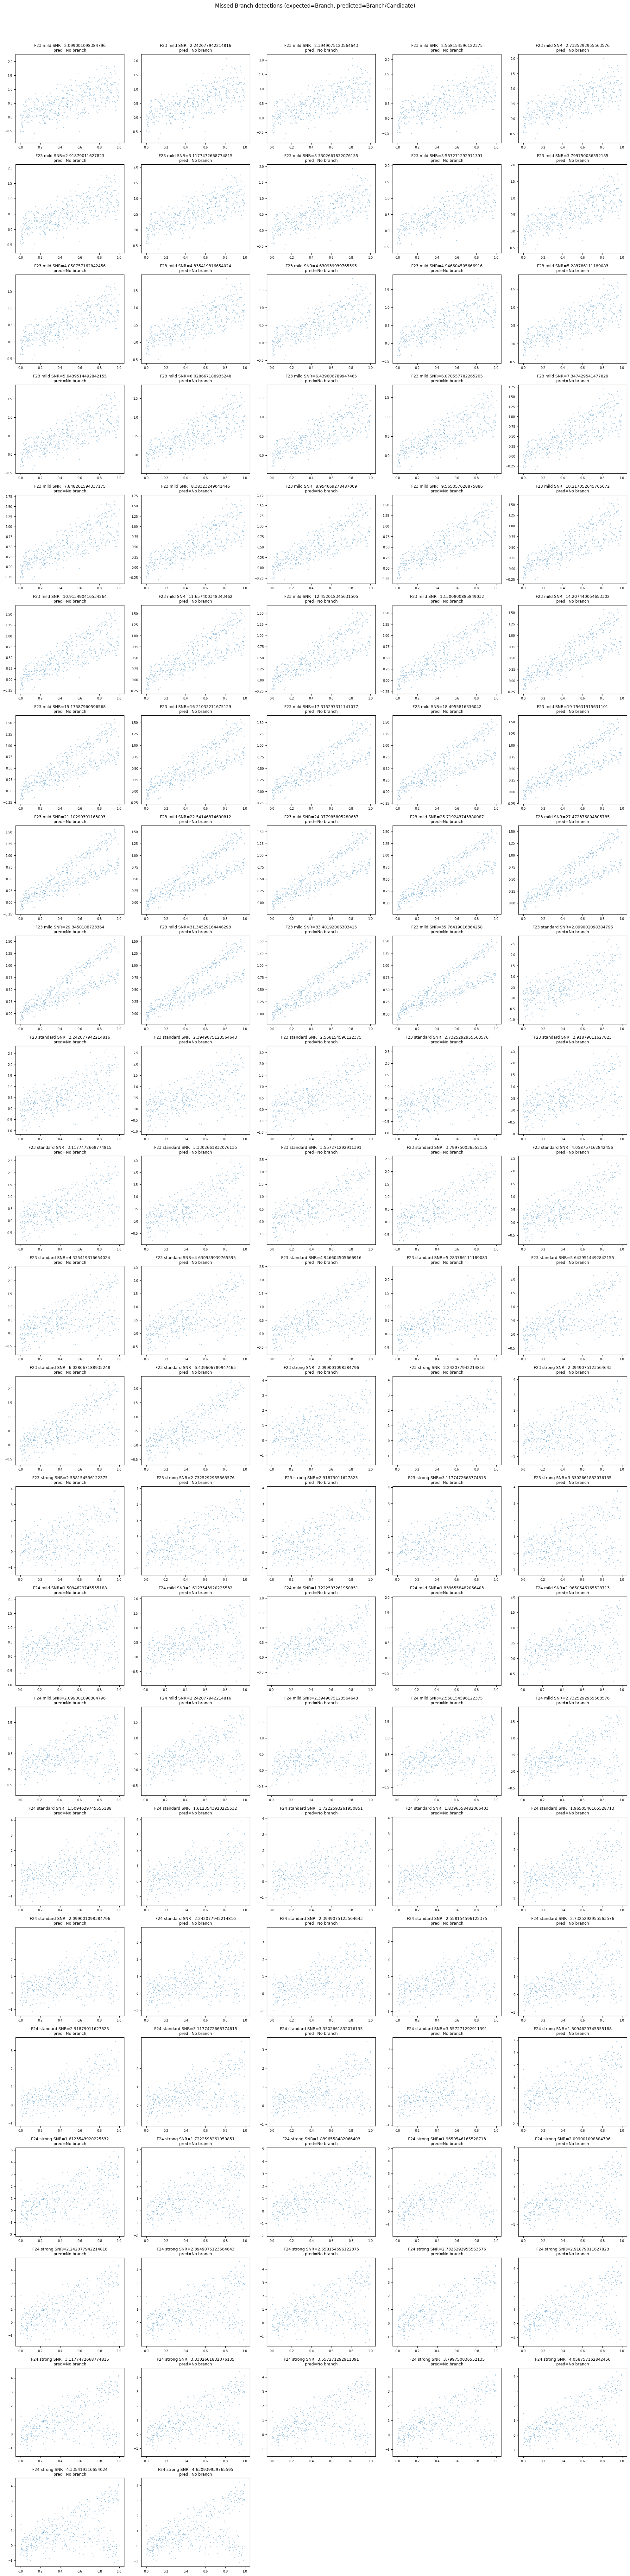

In [13]:
missed = data[
    data['family_id'].isin(FORK_FAMILIES)
    & (data['expected'] == 'Branch')
    & ~data['predicted_group'].isin(['Branch', 'Candidate branch'])
].copy()

print(f'Missed branch cases: {len(missed)}')
print(missed.groupby(['family_id', 'variant_level']).size().to_string())

if len(missed):
    ncols = min(5, len(missed))
    nrows = int(np.ceil(len(missed) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3.5 * nrows),
        squeeze=False,
    )
    for ax in axes.flat:
        ax.set_visible(False)

    for i, row in enumerate(missed.itertuples(index=False)):
        ax = axes[i // ncols, i % ncols]
        ax.set_visible(True)
        idx = int(row.point_index)
        ax.scatter(x_all[idx], y_all[idx], s=4, alpha=0.4, edgecolors='none')
        ax.set_title(
            f'{row.family_id} {row.variant_level} SNR={row.nominal_snr}\n'
            f'pred={row.predicted_group}',
            fontsize=9,
        )
        ax.tick_params(labelsize=7)

    fig.suptitle(
        'Missed Branch detections (expected=Branch, predicted≠Branch/Candidate)',
        fontsize=12, y=1.01,
    )
    fig.tight_layout()
    plt.show()
else:
    print('No missed detections — all expected Branch cases were detected.')

False positive branch cases: 52
family_id  variant_level  predicted_group
F25        mild           Branch             52


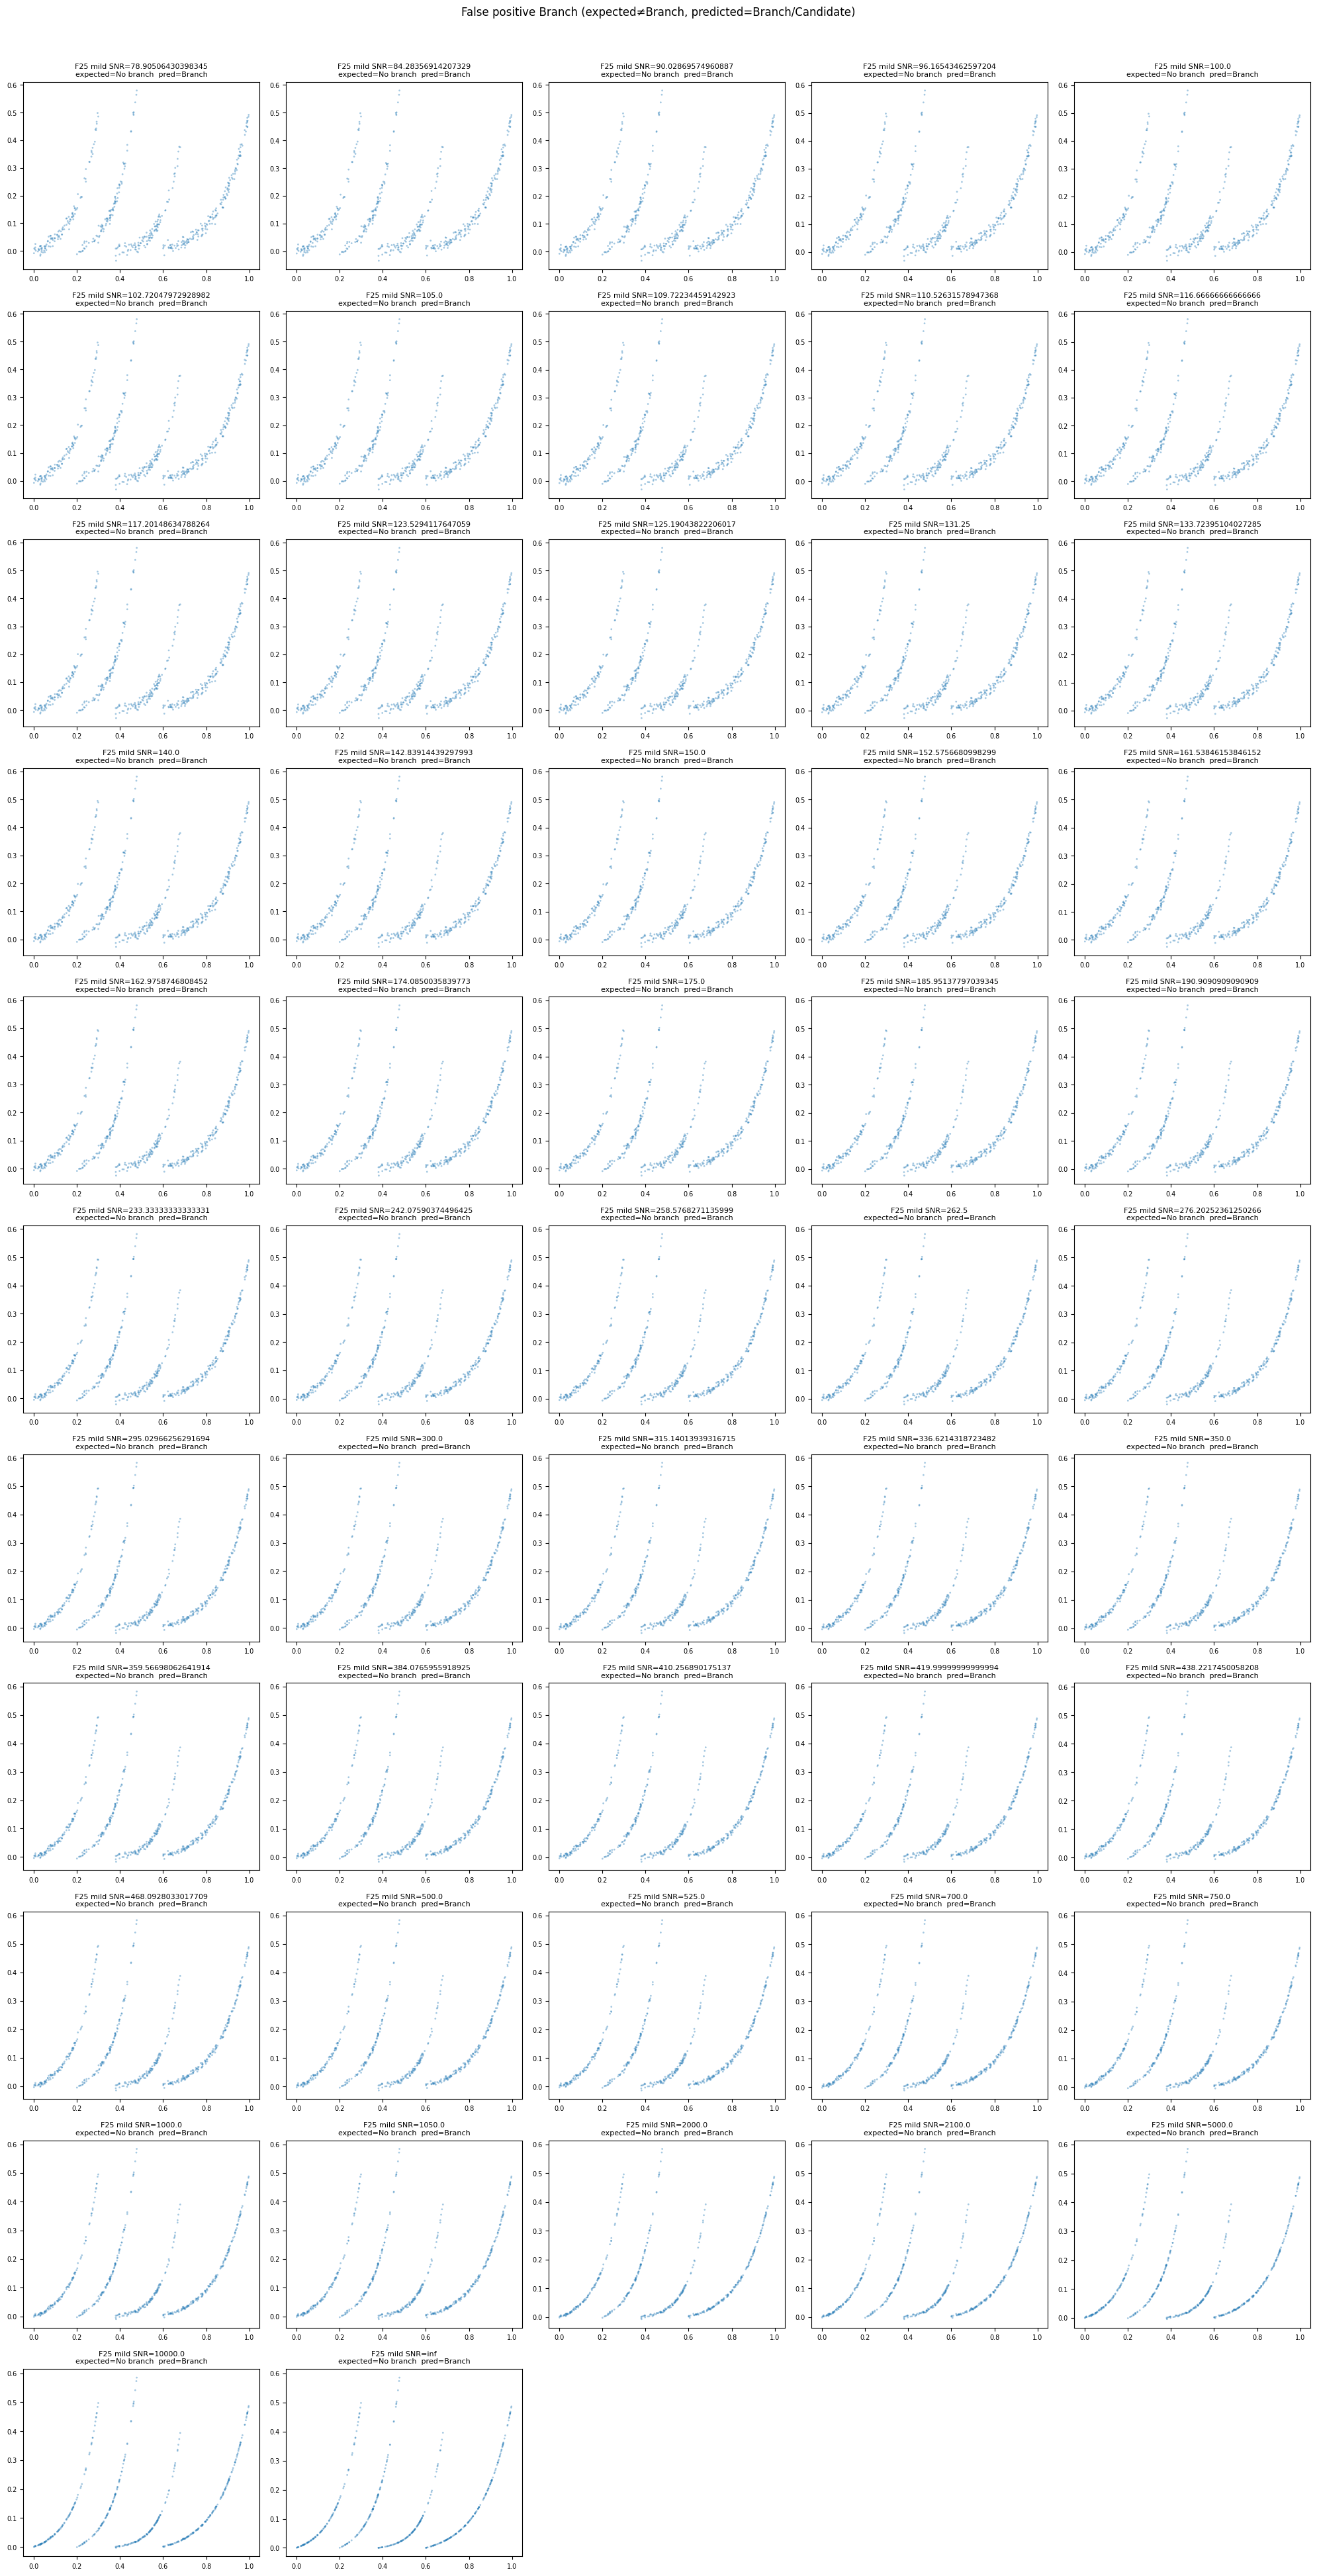

In [14]:
false_pos = data[
    (data['expected'] != 'Branch')
    & data['predicted_group'].isin(['Branch', 'Candidate branch'])
].copy()

print(f'False positive branch cases: {len(false_pos)}')
if len(false_pos):
    print(false_pos.groupby(
        ['family_id', 'variant_level', 'predicted_group'],
    ).size().to_string())

    ncols = min(5, len(false_pos))
    nrows = int(np.ceil(len(false_pos) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3.5 * nrows),
        squeeze=False,
    )
    for ax in axes.flat:
        ax.set_visible(False)

    for i, row in enumerate(false_pos.itertuples(index=False)):
        ax = axes[i // ncols, i % ncols]
        ax.set_visible(True)
        idx = int(row.point_index)
        ax.scatter(x_all[idx], y_all[idx], s=4, alpha=0.4, edgecolors='none')
        ax.set_title(
            f'{row.family_id} {row.variant_level} SNR={row.nominal_snr}\n'
            f'expected={row.expected}  pred={row.predicted_group}',
            fontsize=8,
        )
        ax.tick_params(labelsize=7)

    fig.suptitle(
        'False positive Branch (expected≠Branch, predicted=Branch/Candidate)',
        fontsize=12, y=1.01,
    )
    fig.tight_layout()
    plt.show()
else:
    print('No false positives.')

## Table 2 — Other families (not forks)

F25 and F26 are negatives: overlapping / windowed thresholds are not two ridges
along \(y\) given \(x\). Expected is **No branch** if MIC ≥ 0.20, else
**No Global Relationship**. Candidate branch is still a prediction only.


In [15]:
other_data = data[data['family_id'].isin(OTHER_FAMILIES)].copy()
other_table = diagnostic_with_rates(
    other_data,
    ['No branch', 'No Global Relationship'],
)

print('Table 2 — other families (row % of Expected N)')
print('F25/F26 are included as Not Branch.')
show_full(other_table)

# ------------------------------------------------------------------
# Summary tables — split by variant level
# ------------------------------------------------------------------

other_neg = data[
    data['family_id'].isin(OTHER_FAMILIES)
    & (data['expected'] == 'No branch')
]


def _rate(series: pd.Series, value) -> float:
    if len(series) == 0:
        return float('nan')
    if isinstance(value, (list, tuple, set)):
        return float(series.isin(value).mean())
    return float((series == value).mean())


def _pct(series: pd.Series, value) -> str:
    rate = _rate(series, value)
    return '' if pd.isna(rate) else f'{rate:.1%}'


def _build_summary(fork_pos, neg, label_suffix=''):
    pos_pred = fork_pos['predicted_group']
    neg_pred = neg['predicted_group']
    n_pos = int(len(fork_pos))
    n_neg = int(len(neg))
    n_all = n_pos + n_neg

    acc_pos = _rate(pos_pred, ['Branch', 'Candidate branch'])
    acc_neg = _rate(neg_pred, 'No branch')
    if n_all:
        n_correct_loose = (
            int(pos_pred.isin(['Branch', 'Candidate branch']).sum())
            + int((neg_pred == 'No branch').sum())
        )
        n_correct_strict = (
            int((pos_pred == 'Branch').sum())
            + int((neg_pred == 'No branch').sum())
        )
        acc_overall_loose = n_correct_loose / n_all
        acc_overall_strict = n_correct_strict / n_all
    else:
        acc_overall_loose = acc_overall_strict = float('nan')

    all_pred = pd.concat([pos_pred, neg_pred], ignore_index=True)

    rows = [
        {
            'Evaluation': f'Expected Branch (F23/F24{label_suffix})',
            'N': n_pos,
            'Predicted Branch': _pct(pos_pred, 'Branch'),
            'Predicted Branch or Candidate': _pct(
                pos_pred, ['Branch', 'Candidate branch'],
            ),
            'Predicted No branch': _pct(pos_pred, 'No branch'),
            'Accuracy': '' if pd.isna(acc_pos) else f'{acc_pos:.1%}',
        },
        {
            'Evaluation': 'Expected No branch (other families)',
            'N': n_neg,
            'Predicted Branch': _pct(neg_pred, 'Branch'),
            'Predicted Branch or Candidate': _pct(
                neg_pred, ['Branch', 'Candidate branch'],
            ),
            'Predicted No branch': _pct(neg_pred, 'No branch'),
            'Accuracy': '' if pd.isna(acc_neg) else f'{acc_neg:.1%}',
        },
        {
            'Evaluation': 'Overall',
            'N': n_all,
            'Predicted Branch': _pct(all_pred, 'Branch'),
            'Predicted Branch or Candidate': _pct(
                all_pred, ['Branch', 'Candidate branch'],
            ),
            'Predicted No branch': _pct(all_pred, 'No branch'),
            'Accuracy': (
                '' if pd.isna(acc_overall_loose) else f'{acc_overall_loose:.1%}'
            ),
        },
    ]
    return pd.DataFrame(rows), acc_overall_loose, acc_overall_strict


# --- Summary 3a: standard + strong ---
fork_pos_ss = data[
    data['family_id'].isin(FORK_FAMILIES)
    & (data['expected'] == 'Branch')
    & data['variant_level'].isin(['standard', 'strong'])
]
summary_ss, acc_loose_ss, acc_strict_ss = _build_summary(
    fork_pos_ss, other_neg, label_suffix=', standard+strong',
)

print()
print('=' * 70)
print('Summary 3a — standard + strong')
print('=' * 70)
print(
    'Accuracy: expected Branch counts Branch or Candidate as correct; '
    'expected No branch counts only No branch as correct.'
)
print(
    f'Overall Accuracy: loose = '
    f'{"" if pd.isna(acc_loose_ss) else f"{acc_loose_ss:.1%}"}'
    f'; strict (Branch only on positives) = '
    f'{"" if pd.isna(acc_strict_ss) else f"{acc_strict_ss:.1%}"}.'
)
show_full(summary_ss)

# --- Summary 3b: mild ---
fork_pos_mild = data[
    data['family_id'].isin(FORK_FAMILIES)
    & (data['expected'] == 'Branch')
    & (data['variant_level'] == 'mild')
]
summary_mild, acc_loose_mild, acc_strict_mild = _build_summary(
    fork_pos_mild, other_neg, label_suffix=', mild',
)

print()
print('=' * 70)
print('Summary 3b — mild')
print('=' * 70)
print(
    f'Overall Accuracy: loose = '
    f'{"" if pd.isna(acc_loose_mild) else f"{acc_loose_mild:.1%}"}'
    f'; strict (Branch only on positives) = '
    f'{"" if pd.isna(acc_strict_mild) else f"{acc_strict_mild:.1%}"}.'
)
show_full(summary_mild)

# --- Summary 3c: all variant levels ---
fork_pos_all = data[
    data['family_id'].isin(FORK_FAMILIES)
    & (data['expected'] == 'Branch')
]
summary_all, acc_loose_all, acc_strict_all = _build_summary(
    fork_pos_all, other_neg, label_suffix=', all variants',
)

print()
print('=' * 70)
print('Summary 3c — all variants')
print('=' * 70)
print(
    f'Overall Accuracy: loose = '
    f'{"" if pd.isna(acc_loose_all) else f"{acc_loose_all:.1%}"}'
    f'; strict (Branch only on positives) = '
    f'{"" if pd.isna(acc_strict_all) else f"{acc_strict_all:.1%}"}.'
)
show_full(summary_all)

Table 2 — other families (row % of Expected N)
F25/F26 are included as Not Branch.


,Family,Name,Expected label,Expected N,Branch,Candidate branch,No branch,No Global Relationship
0,F01,Linear positive,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
1,F03,Power convex positive,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
2,F05,Power concave positive,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
3,F07,Saturation positive,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
4,F13,S-curve positive,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
5,F15,Threshold positive,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
6,F18,Quadratic valley (U),No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
7,F19,Spike,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
8,F21,Cubic,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)
9,F22,Oscillation,No branch,681,0 (0.0%),0 (0.0%),681 (100.0%),0 (0.0%)



Summary 3a — standard + strong
Accuracy: expected Branch counts Branch or Candidate as correct; expected No branch counts only No branch as correct.
Overall Accuracy: loose = 98.7%; strict (Branch only on positives) = 98.7%.


,Evaluation,N,Predicted Branch,Predicted Branch or Candidate,Predicted No branch,Accuracy
0,"Expected Branch (F23/F24, standard+strong)",454,87.2%,87.2%,12.8%,87.2%
1,Expected No branch (other families),8172,0.6%,0.6%,99.4%,99.4%
2,Overall,8626,5.2%,5.2%,94.8%,98.7%



Summary 3b — mild
Overall Accuracy: loose = 98.7%; strict (Branch only on positives) = 98.7%.


,Evaluation,N,Predicted Branch,Predicted Branch or Candidate,Predicted No branch,Accuracy
0,"Expected Branch (F23/F24, mild)",227,76.2%,76.2%,23.8%,76.2%
1,Expected No branch (other families),8172,0.6%,0.6%,99.4%,99.4%
2,Overall,8399,2.7%,2.7%,97.3%,98.7%



Summary 3c — all variants
Overall Accuracy: loose = 98.1%; strict (Branch only on positives) = 98.1%.


,Evaluation,N,Predicted Branch,Predicted Branch or Candidate,Predicted No branch,Accuracy
0,"Expected Branch (F23/F24, all variants)",681,83.6%,83.6%,16.4%,83.6%
1,Expected No branch (other families),8172,0.6%,0.6%,99.4%,99.4%
2,Overall,8853,7.0%,7.0%,93.0%,98.1%
